 # **Driver Drowsiness Detection**

### **Dataset Split**

In [4]:
import os
import shutil

source_dir = r"D:\PROJECTS\Capstone_Project_5\Driver_drowsiness_detection_System\Total"

eye_dataset = r"D:\PROJECTS\Capstone_Project_5\Driver_drowsiness_detection_System\Eye_Dataset"
mouth_dataset = r"D:\PROJECTS\Capstone_Project_5\Driver_drowsiness_detection_System\Mouth_Dataset"

# Create folders
for cls in ["open", "closed"]:
    os.makedirs(os.path.join(eye_dataset, cls), exist_ok=True)

for cls in ["yawn", "no_yawn"]:
    os.makedirs(os.path.join(mouth_dataset, cls), exist_ok=True)

# Copy eye images
for cls in ["open", "closed"]:
    src = os.path.join(source_dir, cls)
    dst = os.path.join(eye_dataset, cls)

    for file in os.listdir(src):
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            shutil.copy(
                os.path.join(src, file),
                os.path.join(dst, file)
            )

# Copy mouth images
for cls in ["yawn", "no_yawn"]:
    src = os.path.join(source_dir, cls)
    dst = os.path.join(mouth_dataset, cls)

    for file in os.listdir(src):
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            shutil.copy(
                os.path.join(src, file),
                os.path.join(dst, file)
            )

print("Datasets created successfully.")

Datasets created successfully.


### **Train/test/Val Split**

In [5]:
import os
import random
import shutil

def split_dataset(dataset_path):

    classes = [
        cls for cls in os.listdir(dataset_path)
        if os.path.isdir(os.path.join(dataset_path, cls))
        and cls not in ["train", "val", "test"]
    ]

    for cls in classes:

        cls_path = os.path.join(dataset_path, cls)

        images = [
            img for img in os.listdir(cls_path)
            if img.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        random.shuffle(images)

        total = len(images)

        train_end = int(0.70 * total)
        val_end = int(0.85 * total)

        splits = {
            "train": images[:train_end],
            "val": images[train_end:val_end],
            "test": images[val_end:]
        }

        for split, files in splits.items():

            split_dir = os.path.join(dataset_path, split, cls)

            os.makedirs(split_dir, exist_ok=True)

            for file in files:

                src = os.path.join(cls_path, file)
                dst = os.path.join(split_dir, file)

                if not os.path.exists(dst):
                    shutil.copy(src, dst)

    print(f"{dataset_path} split completed.")

In [6]:
split_dataset("Eye_Dataset")
split_dataset("Mouth_Dataset")

Eye_Dataset split completed.
Mouth_Dataset split completed.


In [7]:
def count_images(path):

    for split in ["train", "val", "test"]:

        print(f"\n{split.upper()}")

        split_path = os.path.join(path, split)

        for cls in os.listdir(split_path):

            cls_path = os.path.join(split_path, cls)

            print(
                cls,
                len(os.listdir(cls_path))
            )

In [8]:
count_images("Eye_Dataset")
count_images("Mouth_Dataset")


TRAIN
closed 508
open 508

VAL
closed 109
open 109

TEST
closed 109
open 109

TRAIN
no_yawn 507
yawn 506

VAL
no_yawn 109
yawn 108

TEST
no_yawn 109
yawn 109


## **MobileNetV2 Model**

### **Eye Model**

In [9]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# =====================================================
# CONFIG
# =====================================================

DATASET_PATH = "Eye_Dataset"

BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 0.0001

MODEL_PATH = "eye_model.pth"

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

# =====================================================
# TRANSFORMS
# =====================================================

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

# =====================================================
# DATASETS
# =====================================================

train_ds = datasets.ImageFolder(
    os.path.join(DATASET_PATH, "train"),
    transform=train_transform
)

val_ds = datasets.ImageFolder(
    os.path.join(DATASET_PATH, "val"),
    transform=test_transform
)

test_ds = datasets.ImageFolder(
    os.path.join(DATASET_PATH, "test"),
    transform=test_transform
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Classes:", train_ds.classes)

# =====================================================
# MODEL
# =====================================================

model = models.mobilenet_v2(weights="DEFAULT")

# Freeze feature extractor
for param in model.features.parameters():
    param.requires_grad = False

# Replace classifier
model.classifier[1] = nn.Linear(
    model.last_channel,
    len(train_ds.classes)
)

model = model.to(device)

# =====================================================
# LOSS & OPTIMIZER
# =====================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

# =====================================================
# TRAINING
# =====================================================

best_val_acc = 0

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # =====================================
    # VALIDATION
    # =====================================

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    val_acc = 100 * correct / total

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Loss: {running_loss:.4f} "
        f"Val Acc: {val_acc:.2f}%"
    )

    # =====================================
    # SAVE BEST MODEL
    # =====================================

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save({
            "model_state": model.state_dict(),
            "classes": train_ds.classes
        }, MODEL_PATH)

        print(f"✅ Best model saved ({val_acc:.2f}%)")

# =====================================================
# TEST ACCURACY
# =====================================================

checkpoint = torch.load(
    MODEL_PATH,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state"]
)

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

test_acc = 100 * correct / total

print("\n==========================")
print(f"Best Validation Accuracy : {best_val_acc:.2f}%")
print(f"Test Accuracy            : {test_acc:.2f}%")
print("==========================")

Device: cpu
Classes: ['closed', 'open']
Epoch [1/15] Loss: 21.5026 Val Acc: 64.68%
✅ Best model saved (64.68%)
Epoch [2/15] Loss: 19.9780 Val Acc: 78.44%
✅ Best model saved (78.44%)
Epoch [3/15] Loss: 18.5967 Val Acc: 85.32%
✅ Best model saved (85.32%)
Epoch [4/15] Loss: 17.2932 Val Acc: 88.99%
✅ Best model saved (88.99%)
Epoch [5/15] Loss: 16.2306 Val Acc: 89.45%
✅ Best model saved (89.45%)
Epoch [6/15] Loss: 15.2136 Val Acc: 90.37%
✅ Best model saved (90.37%)
Epoch [7/15] Loss: 14.2747 Val Acc: 89.45%
Epoch [8/15] Loss: 13.6701 Val Acc: 90.37%
Epoch [9/15] Loss: 13.0209 Val Acc: 90.83%
✅ Best model saved (90.83%)
Epoch [10/15] Loss: 12.1668 Val Acc: 91.28%
✅ Best model saved (91.28%)
Epoch [11/15] Loss: 11.5949 Val Acc: 91.28%
Epoch [12/15] Loss: 11.2590 Val Acc: 91.74%
✅ Best model saved (91.74%)
Epoch [13/15] Loss: 11.1056 Val Acc: 90.83%
Epoch [14/15] Loss: 10.8831 Val Acc: 91.74%
Epoch [15/15] Loss: 10.2822 Val Acc: 91.74%

Best Validation Accuracy : 91.74%
Test Accuracy         


Confusion Matrix:
[[ 96  13]
 [  7 102]]

Classification Report:
              precision    recall  f1-score   support

      closed       0.93      0.88      0.91       109
        open       0.89      0.94      0.91       109

    accuracy                           0.91       218
   macro avg       0.91      0.91      0.91       218
weighted avg       0.91      0.91      0.91       218



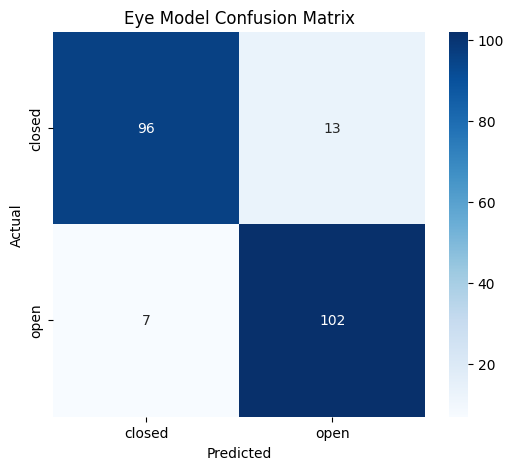

In [10]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------
# COLLECT PREDICTIONS
# ----------------------------

y_true = []
y_pred = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# ----------------------------
# CONFUSION MATRIX
# ----------------------------

cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix:")
print(cm)

# ----------------------------
# CLASSIFICATION REPORT
# ----------------------------

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=train_ds.classes
    )
)

# ----------------------------
# PLOT MATRIX
# ----------------------------

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=train_ds.classes,
    yticklabels=train_ds.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Eye Model Confusion Matrix")

plt.show()

### **Mouth Image Crop**

In [11]:
import os
import cv2
from mediapipe.python.solutions import face_mesh

# =====================================================
# CONFIG
# =====================================================

SOURCE_DATASET = "Mouth_Dataset"
OUTPUT_DATASET = "Mouth_Crop_Dataset"

# FaceMesh
mp_face_mesh = face_mesh

# Mouth landmarks
MOUTH_POINTS = [
    61, 146, 91, 181, 84, 17,
    314, 405, 321, 375, 291, 308,
    78, 95, 88, 178, 87, 14,
    317, 402, 318, 324
]

# =====================================================
# CREATE OUTPUT FOLDERS
# =====================================================

for split in ["train", "val", "test"]:
    for cls in ["yawn", "no_yawn"]:
        os.makedirs(
            os.path.join(
                OUTPUT_DATASET,
                split,
                cls
            ),
            exist_ok=True
        )

# =====================================================
# FACEMESH
# =====================================================

with mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5
) as mesh:

    for split in ["train", "val", "test"]:

        print(f"\nProcessing {split.upper()}")

        for cls in ["yawn", "no_yawn"]:

            src_folder = os.path.join(
                SOURCE_DATASET,
                split,
                cls
            )

            dst_folder = os.path.join(
                OUTPUT_DATASET,
                split,
                cls
            )

            count = 0
            skipped = 0

            for file in os.listdir(src_folder):

                if not file.lower().endswith(
                    (".jpg", ".jpeg", ".png")
                ):
                    continue

                img_path = os.path.join(
                    src_folder,
                    file
                )

                image = cv2.imread(img_path)

                if image is None:
                    skipped += 1
                    continue

                h, w = image.shape[:2]

                rgb = cv2.cvtColor(
                    image,
                    cv2.COLOR_BGR2RGB
                )

                results = mesh.process(rgb)

                if not results.multi_face_landmarks:
                    skipped += 1
                    continue

                landmarks = (
                    results
                    .multi_face_landmarks[0]
                    .landmark
                )

                xs = []
                ys = []

                for idx in MOUTH_POINTS:

                    x = int(
                        landmarks[idx].x * w
                    )

                    y = int(
                        landmarks[idx].y * h
                    )

                    xs.append(x)
                    ys.append(y)

                # Bounding box
                padding = 25

                x_min = max(min(xs) - padding, 0)
                y_min = max(min(ys) - padding, 0)

                x_max = min(max(xs) + padding, w)
                y_max = min(max(ys) + padding, h)

                mouth_crop = image[
                    y_min:y_max,
                    x_min:x_max
                ]

                if mouth_crop.size == 0:
                    skipped += 1
                    continue

                save_path = os.path.join(
                    dst_folder,
                    file
                )

                cv2.imwrite(
                    save_path,
                    mouth_crop
                )

                count += 1

            print(
                f"{cls}: "
                f"{count} saved | "
                f"{skipped} skipped"
            )

print("\n✅ Mouth crop dataset created successfully!")


Processing TRAIN


d:\PROJECTS\Capstone_Project_5\.DDD\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


yawn: 505 saved | 1 skipped
no_yawn: 506 saved | 1 skipped

Processing VAL
yawn: 108 saved | 0 skipped
no_yawn: 109 saved | 0 skipped

Processing TEST
yawn: 109 saved | 0 skipped
no_yawn: 109 saved | 0 skipped

✅ Mouth crop dataset created successfully!


### **Mouth Model**

Device: cpu
Classes: ['no_yawn', 'yawn']
Epoch [1/15] Loss: 21.9247 Val Acc: 62.67%
✅ Best model saved (62.67%)
Epoch [2/15] Loss: 20.0535 Val Acc: 76.96%
✅ Best model saved (76.96%)
Epoch [3/15] Loss: 18.4493 Val Acc: 83.41%
✅ Best model saved (83.41%)
Epoch [4/15] Loss: 17.2779 Val Acc: 85.71%
✅ Best model saved (85.71%)
Epoch [5/15] Loss: 16.4249 Val Acc: 86.64%
✅ Best model saved (86.64%)
Epoch [6/15] Loss: 15.2099 Val Acc: 89.86%
✅ Best model saved (89.86%)
Epoch [7/15] Loss: 14.5928 Val Acc: 88.02%
Epoch [8/15] Loss: 13.8528 Val Acc: 90.32%
✅ Best model saved (90.32%)
Epoch [9/15] Loss: 13.1030 Val Acc: 89.40%
Epoch [10/15] Loss: 12.8295 Val Acc: 90.32%
Epoch [11/15] Loss: 12.0577 Val Acc: 89.40%
Epoch [12/15] Loss: 11.6206 Val Acc: 90.32%
Epoch [13/15] Loss: 11.2833 Val Acc: 90.32%
Epoch [14/15] Loss: 10.6648 Val Acc: 90.78%
✅ Best model saved (90.78%)
Epoch [15/15] Loss: 10.3069 Val Acc: 90.32%

Best Validation Accuracy : 90.78%
Test Accuracy            : 93.58%

Confusion Matr

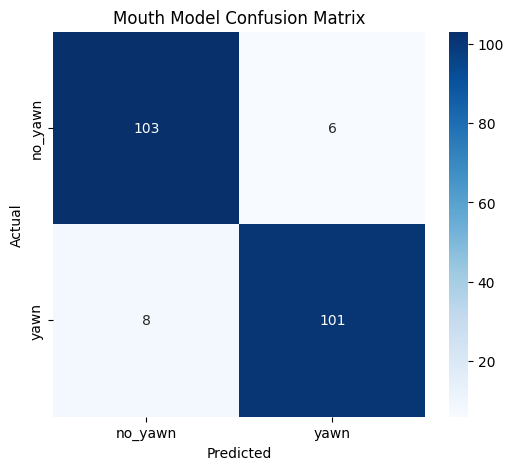

In [12]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# =====================================================
# CONFIG
# =====================================================

DATASET_PATH = "Mouth_Crop_Dataset"
MODEL_PATH = "mouth_crop_model.pth"

BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 0.0001


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

# =====================================================
# TRANSFORMS
# =====================================================

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

# =====================================================
# DATASET
# =====================================================

train_ds = datasets.ImageFolder(
    os.path.join(DATASET_PATH, "train"),
    transform=train_transform
)

val_ds = datasets.ImageFolder(
    os.path.join(DATASET_PATH, "val"),
    transform=test_transform
)

test_ds = datasets.ImageFolder(
    os.path.join(DATASET_PATH, "test"),
    transform=test_transform
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Classes:", train_ds.classes)

# =====================================================
# MODEL
# =====================================================

model = models.mobilenet_v2(weights="DEFAULT")

# Freeze feature extractor
for param in model.features.parameters():
    param.requires_grad = False

# Replace classifier
model.classifier[1] = nn.Linear(
    model.last_channel,
    len(train_ds.classes)
)

model = model.to(device)

# =====================================================
# LOSS & OPTIMIZER
# =====================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

# =====================================================
# TRAINING
# =====================================================

best_val_acc = 0

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # =====================================
    # VALIDATION
    # =====================================

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    val_acc = 100 * correct / total

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Loss: {running_loss:.4f} "
        f"Val Acc: {val_acc:.2f}%"
    )

    # =====================================
    # SAVE BEST MODEL
    # =====================================

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save({
            "model_state": model.state_dict(),
            "classes": train_ds.classes
        }, MODEL_PATH)

        print(f"✅ Best model saved ({val_acc:.2f}%)")

# =====================================================
# LOAD BEST MODEL
# =====================================================

checkpoint = torch.load(
    MODEL_PATH,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state"]
)

model.eval()

# =====================================================
# TEST ACCURACY
# =====================================================

correct = 0
total = 0

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

test_acc = 100 * correct / total

print("\n==========================")
print(f"Best Validation Accuracy : {best_val_acc:.2f}%")
print(f"Test Accuracy            : {test_acc:.2f}%")
print("==========================")

# =====================================================
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=train_ds.classes
    )
)

# =====================================================
# PLOT CONFUSION MATRIX
# =====================================================

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=train_ds.classes,
    yticklabels=train_ds.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Mouth Model Confusion Matrix")

plt.show()

# **CNN Model**

### **Eye Model**

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# =====================================================
# CONFIG
# =====================================================

DATASET_PATH = "Eye_Dataset"

BATCH_SIZE = 32
EPOCHS = 15
LR = 0.001

MODEL_PATH = "cnn_eye_model.pth"

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

# =====================================================
# TRANSFORMS
# =====================================================

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5,0.5,0.5),
        (0.5,0.5,0.5)
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5,0.5,0.5),
        (0.5,0.5,0.5)
    )
])

# =====================================================
# DATASETS
# =====================================================

train_ds = datasets.ImageFolder(
    f"{DATASET_PATH}/train",
    transform=train_transform
)

val_ds = datasets.ImageFolder(
    f"{DATASET_PATH}/val",
    transform=test_transform
)

test_ds = datasets.ImageFolder(
    f"{DATASET_PATH}/test",
    transform=test_transform
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Classes:", train_ds.classes)

# =====================================================
# CNN MODEL
# =====================================================

class EyeCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                128,
                256,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                256 * 14 * 14,
                512
            ),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(
                512,
                2
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

# =====================================================
# MODEL
# =====================================================

model = EyeCNN().to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LR
)

# =====================================================
# VALIDATION
# =====================================================

def evaluate(loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            _, preds = torch.max(
                outputs,
                1
            )

            correct += (
                preds == labels
            ).sum().item()

            total += labels.size(0)

    return 100 * correct / total

# =====================================================
# TRAINING
# =====================================================

best_val_acc = 0

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    val_acc = evaluate(
        val_loader
    )

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Loss: {running_loss:.4f} "
        f"Val Acc: {val_acc:.2f}%"
    )

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save({

            "model_state":
                model.state_dict(),

            "classes":
                train_ds.classes

        }, MODEL_PATH)

        print(
            f"✅ Best model saved "
            f"({val_acc:.2f}%)"
        )

# =====================================================
# FINAL TEST
# =====================================================

checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state"]
)

test_acc = evaluate(
    test_loader
)

print("\n==========================")
print(
    f"Best Validation Accuracy : "
    f"{best_val_acc:.2f}%"
)
print(
    f"Test Accuracy            : "
    f"{test_acc:.2f}%"
)
print("==========================")

Device: cpu
Classes: ['closed', 'open']
Epoch [1/15] Loss: 23.2484 Val Acc: 74.77%
✅ Best model saved (74.77%)
Epoch [2/15] Loss: 14.3687 Val Acc: 91.74%
✅ Best model saved (91.74%)
Epoch [3/15] Loss: 10.2184 Val Acc: 95.41%
✅ Best model saved (95.41%)
Epoch [4/15] Loss: 7.2595 Val Acc: 94.95%
Epoch [5/15] Loss: 5.4427 Val Acc: 96.33%
✅ Best model saved (96.33%)
Epoch [6/15] Loss: 5.1560 Val Acc: 95.41%
Epoch [7/15] Loss: 4.8537 Val Acc: 98.17%
✅ Best model saved (98.17%)
Epoch [8/15] Loss: 3.8026 Val Acc: 98.17%
Epoch [9/15] Loss: 3.7683 Val Acc: 96.33%
Epoch [10/15] Loss: 4.7085 Val Acc: 99.08%
✅ Best model saved (99.08%)
Epoch [11/15] Loss: 3.7084 Val Acc: 96.79%
Epoch [12/15] Loss: 3.0954 Val Acc: 98.17%
Epoch [13/15] Loss: 2.8745 Val Acc: 97.71%
Epoch [14/15] Loss: 3.2447 Val Acc: 98.17%
Epoch [15/15] Loss: 2.4565 Val Acc: 97.71%

Best Validation Accuracy : 99.08%
Test Accuracy            : 95.87%


In [14]:
import torch
import numpy as np

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

# ====================================
# LOAD BEST MODEL
# ====================================

checkpoint = torch.load(
    "cnn_eye_model.pth",
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state"]
)

model.eval()

# ====================================
# PREDICTIONS
# ====================================

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)

        outputs = model(images)

        _, preds = torch.max(
            outputs,
            1
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

# ====================================
# CONFUSION MATRIX
# ====================================

cm = confusion_matrix(
    all_labels,
    all_preds
)

print("\nConfusion Matrix:")
print(cm)

# ====================================
# CLASSIFICATION REPORT
# ====================================

print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=train_ds.classes
    )
)


Confusion Matrix:
[[102   7]
 [  2 107]]

Classification Report:

              precision    recall  f1-score   support

      closed       0.98      0.94      0.96       109
        open       0.94      0.98      0.96       109

    accuracy                           0.96       218
   macro avg       0.96      0.96      0.96       218
weighted avg       0.96      0.96      0.96       218



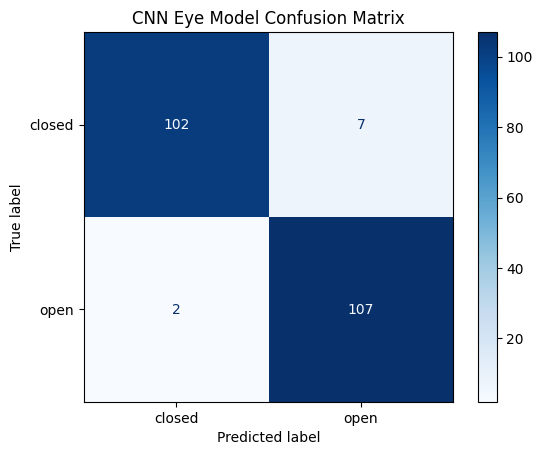

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_ds.classes
)

disp.plot(cmap="Blues")

plt.title("CNN Eye Model Confusion Matrix")

plt.show()

### **Mouth Model**

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# =====================================================
# CONFIG
# =====================================================

DATASET_PATH = "Mouth_Crop_Dataset"

BATCH_SIZE = 32
EPOCHS = 15
LR = 0.001

MODEL_PATH = "cnn_mouth_model.pth"

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

# =====================================================
# TRANSFORMS
# =====================================================

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5,0.5,0.5),
        (0.5,0.5,0.5)
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5,0.5,0.5),
        (0.5,0.5,0.5)
    )
])

# =====================================================
# DATASET
# =====================================================

train_ds = datasets.ImageFolder(
    f"{DATASET_PATH}/train",
    transform=train_transform
)

val_ds = datasets.ImageFolder(
    f"{DATASET_PATH}/val",
    transform=test_transform
)

test_ds = datasets.ImageFolder(
    f"{DATASET_PATH}/test",
    transform=test_transform
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Classes:", train_ds.classes)

# =====================================================
# CNN MODEL
# =====================================================

class MouthCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                3, 32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                32, 64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                64, 128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                128, 256,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                256 * 14 * 14,
                512
            ),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(
                512,
                len(train_ds.classes)
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

# =====================================================
# MODEL
# =====================================================

model = MouthCNN().to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LR
)

# =====================================================
# VALIDATION
# =====================================================

def evaluate(loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            _, preds = torch.max(
                outputs,
                1
            )

            correct += (
                preds == labels
            ).sum().item()

            total += labels.size(0)

    return 100 * correct / total

# =====================================================
# TRAIN
# =====================================================

best_val_acc = 0

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    val_acc = evaluate(
        val_loader
    )

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Loss: {running_loss:.4f} "
        f"Val Acc: {val_acc:.2f}%"
    )

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save({

            "model_state":
                model.state_dict(),

            "classes":
                train_ds.classes

        }, MODEL_PATH)

        print(
            f"✅ Best model saved "
            f"({val_acc:.2f}%)"
        )

# =====================================================
# TEST
# =====================================================

checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state"]
)

test_acc = evaluate(
    test_loader
)

print("\n==========================")
print(
    f"Best Validation Accuracy : "
    f"{best_val_acc:.2f}%"
)
print(
    f"Test Accuracy            : "
    f"{test_acc:.2f}%"
)
print("==========================")

Device: cpu
Classes: ['no_yawn', 'yawn']
Epoch [1/15] Loss: 19.5658 Val Acc: 88.94%
✅ Best model saved (88.94%)
Epoch [2/15] Loss: 10.1369 Val Acc: 96.31%
✅ Best model saved (96.31%)
Epoch [3/15] Loss: 5.4989 Val Acc: 92.17%
Epoch [4/15] Loss: 4.8881 Val Acc: 96.77%
✅ Best model saved (96.77%)
Epoch [5/15] Loss: 3.6501 Val Acc: 97.70%
✅ Best model saved (97.70%)
Epoch [6/15] Loss: 2.5446 Val Acc: 96.77%
Epoch [7/15] Loss: 1.7778 Val Acc: 99.54%
✅ Best model saved (99.54%)
Epoch [8/15] Loss: 1.3923 Val Acc: 99.54%
Epoch [9/15] Loss: 2.0816 Val Acc: 99.08%
Epoch [10/15] Loss: 1.7435 Val Acc: 98.16%
Epoch [11/15] Loss: 1.7080 Val Acc: 98.16%
Epoch [12/15] Loss: 1.7431 Val Acc: 99.54%
Epoch [13/15] Loss: 0.9382 Val Acc: 99.54%
Epoch [14/15] Loss: 1.1405 Val Acc: 98.62%
Epoch [15/15] Loss: 1.7704 Val Acc: 99.54%

Best Validation Accuracy : 99.54%
Test Accuracy            : 97.71%


In [17]:
import torch
import numpy as np

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

# ==================================
# LOAD BEST MODEL
# ==================================

checkpoint = torch.load(
    "cnn_mouth_model.pth",
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state"]
)

model.eval()

# ==================================
# PREDICTIONS
# ==================================

all_labels = []
all_preds = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)

        outputs = model(images)

        _, preds = torch.max(
            outputs,
            1
        )

        all_labels.extend(
            labels.numpy()
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

# ==================================
# CONFUSION MATRIX
# ==================================

cm = confusion_matrix(
    all_labels,
    all_preds
)

print("\nConfusion Matrix:")
print(cm)

# ==================================
# CLASSIFICATION REPORT
# ==================================

print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=train_ds.classes
    )
)


Confusion Matrix:
[[108   1]
 [  4 105]]

Classification Report:

              precision    recall  f1-score   support

     no_yawn       0.96      0.99      0.98       109
        yawn       0.99      0.96      0.98       109

    accuracy                           0.98       218
   macro avg       0.98      0.98      0.98       218
weighted avg       0.98      0.98      0.98       218



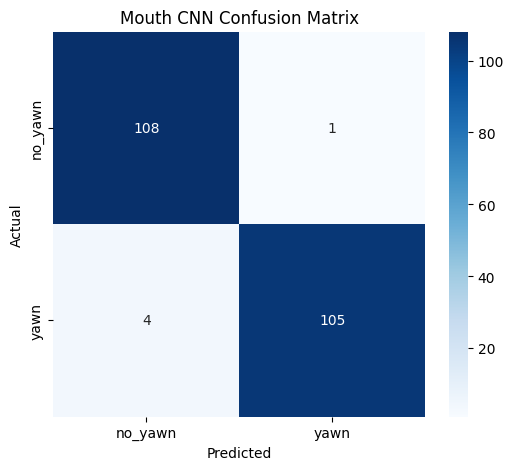

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=train_ds.classes,
    yticklabels=train_ds.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Mouth CNN Confusion Matrix")

plt.show()